In [79]:
import pandas as pd
import importlib
import funciones as func #Tener funciones.py en mismo directorio. Tiene las funciones usadas para procesar un df
importlib.reload(func)

<module 'funciones' from 'c:\\Users\\dafyd\\Documents\\Escuela\\2025\\semestre 1\\TD6\\TP2\\last_day\\funciones.py'>

In [80]:
data = pd.read_csv('../competition_data.csv')

In [81]:
import csv
f = open('../uri_to_duration.csv', 'r')
diccionario = {}
for line in csv.DictReader(f):
    diccionario[line['uri']] = float(line['duration'])
f.close()
diccionario

{'spotify:track:3jFfr89lnSmb4QBtfG8JBP': 187120.0,
 'spotify:track:09TTeexnlKewZdjOak2sV2': 292573.0,
 'spotify:track:0G3fbPbE1vGeABDEZF0jeG': 495400.0,
 'spotify:track:1NXvuBAq48QrxRFQZVmORQ': 430960.0,
 'spotify:track:2gYJY0sIx1ErgTIha2nPRg': 214848.0,
 'spotify:track:0njXuAkJVSpptzKniMBtIZ': 405499.0,
 'spotify:track:7Kszjzps0xbQXyo1pO4KfE': 331360.0,
 'spotify:track:39KmBOGkD1ztCbVeo2uspA': 277560.0,
 'spotify:track:0UAEHlFR79k9CJvknSGUNf': 215040.0,
 'spotify:track:1sWeSMifj6Z6kZyI6z3bRc': 171040.0,
 'spotify:track:0nLiqZ6A27jJri2VCalIUs': 388266.0,
 'spotify:track:1Ig4pCPanhzXl7C86MmBUc': 161133.0,
 'spotify:track:0WtDGnWL2KrMCk0mI1Gpwz': 326933.0,
 'spotify:track:326HJ8o8XJff8dSZOwe4GS': 288586.0,
 'spotify:track:1bSpwPhAxZwlR2enJJsv7U': 229120.0,
 'spotify:track:5luOvrlnzfvJQdQjrScVj4': 249500.0,
 'spotify:track:1SJtlNRJDeYHioymcvsqev': 216391.0,
 'spotify:track:06pjQCIybMiGrgtHODGa2m': 225906.0,
 'spotify:track:6eJlEcRmeyQfTlDQBDyqkW': 156680.0,
 'spotify:track:6A64S6NPQwA5KIQ

In [82]:
data = func.sort_by_ts(data)

In [83]:
# Toma aleatoriamente el 80 % de las filas
train = data.sample(frac=0.7, random_state=42).copy()

# El resto (20 %) lo podés obtener excluyendo esos índices
validation   = data.drop(train.index).copy()

In [84]:
data = func.procesar_df(data, diccionario)
train = func.procesar_df(train, diccionario)
validation = func.procesar_df_2(validation, diccionario)

In [85]:
validation = validation.merge(
    data[['Unnamed: 0', 'is_early_finish', 'racha_skips_prev']],
    on='Unnamed: 0',
    how='left'
)

In [86]:
validation = validation[['Unnamed: 0', 'ts', 'platform', 'master_metadata_track_name',
       'master_metadata_album_artist_name', 'master_metadata_album_album_name',
       'spotify_track_uri', 'reason_start', 'shuffle', 'TARGET', 'hour',
       'day_of_week', 'month', 'year', 'is_iphone', 'duration_ms',
       'is_early_finish', 'racha_skips_prev', 'reason_appload', 'reason_backbtn',
       'reason_clickrow', 'reason_fwdbtn', 'reason_playbtn', 'reason_remote',
       'reason_trackdone', 'reason_trackerror', 'reason_unknown', 'track_prop',
       'artist_prop', 'album_prop', 'hour day_of_week']]

In [87]:
import xgboost as xgb

drop_cols = [
    'Unnamed: 0','ts', 'platform', 'reason_start',
    'master_metadata_track_name',
    'master_metadata_album_artist_name',
    'master_metadata_album_album_name',
    'spotify_track_uri','platform', 'TARGET'
]
clf_xgb = xgb.XGBClassifier(objective = 'binary:logistic',
                            seed = 42,
                            eval_metric = 'auc',
                            early_stopping_rounds = 100)
clf_xgb.fit(train.drop(columns=drop_cols),
                train['TARGET'],
                eval_set=[(validation.drop(columns=drop_cols), validation['TARGET'])],
                verbose=True
                )

[0]	validation_0-auc:0.96035
[1]	validation_0-auc:0.96136
[2]	validation_0-auc:0.96207
[3]	validation_0-auc:0.96291
[4]	validation_0-auc:0.96268
[5]	validation_0-auc:0.96304
[6]	validation_0-auc:0.96328
[7]	validation_0-auc:0.96362
[8]	validation_0-auc:0.96377
[9]	validation_0-auc:0.96389
[10]	validation_0-auc:0.96416
[11]	validation_0-auc:0.96435
[12]	validation_0-auc:0.96441
[13]	validation_0-auc:0.96452
[14]	validation_0-auc:0.96461
[15]	validation_0-auc:0.96519
[16]	validation_0-auc:0.96531
[17]	validation_0-auc:0.96562
[18]	validation_0-auc:0.96561
[19]	validation_0-auc:0.96579
[20]	validation_0-auc:0.96589
[21]	validation_0-auc:0.96617
[22]	validation_0-auc:0.96621
[23]	validation_0-auc:0.96625
[24]	validation_0-auc:0.96652
[25]	validation_0-auc:0.96664
[26]	validation_0-auc:0.96666
[27]	validation_0-auc:0.96671
[28]	validation_0-auc:0.96671
[29]	validation_0-auc:0.96678
[30]	validation_0-auc:0.96680
[31]	validation_0-auc:0.96682
[32]	validation_0-auc:0.96681
[33]	validation_0-au

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=100,
              enable_categorical=False, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

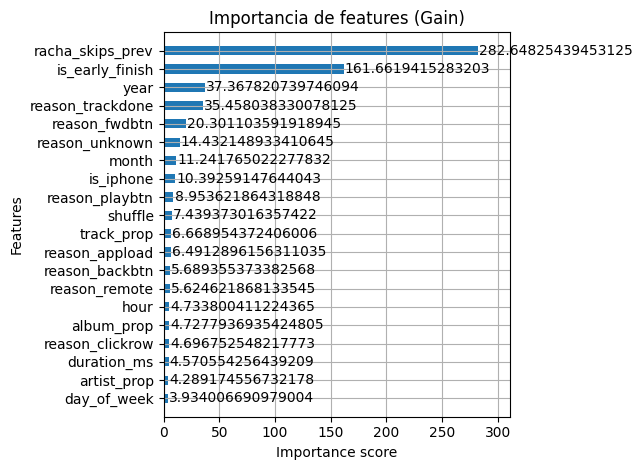

In [88]:
import matplotlib.pyplot as plt
xgb.plot_importance(clf_xgb, importance_type='gain', max_num_features=20, height=0.5)
plt.title("Importancia de features (Gain)")
plt.tight_layout()
plt.show()

In [89]:
from sklearn.metrics import roc_auc_score

best = clf_xgb.best_iteration
print(best)

prediccion_val = clf_xgb.predict_proba(validation.drop(columns=drop_cols))[:, 1]
auc = roc_auc_score(validation['TARGET'], prediccion_val)
print(f"AUC-ROC: {auc:.4f}")

48
AUC-ROC: 0.9673
